### Importação dos dados



In [123]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)


loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento



In [124]:
soma_loja_1 = sum(loja["Preço"])
soma_loja_2 = sum(loja2["Preço"])
soma_loja_3 = sum(loja3["Preço"])
soma_loja_4 = sum(loja4["Preço"])

lojas = ["Loja 1", "Loja 2", "Loja 3", "Loja 4"]
faturamento_lojas = [soma_loja_1, soma_loja_2, soma_loja_3, soma_loja_4]

for i in range (0,4):
    print(f"{lojas[i]} = Faturamento de R${faturamento_lojas[i]:,.2f}")

Loja 1 = Faturamento de R$1,534,509.12
Loja 2 = Faturamento de R$1,488,459.06
Loja 3 = Faturamento de R$1,464,025.03
Loja 4 = Faturamento de R$1,384,497.58


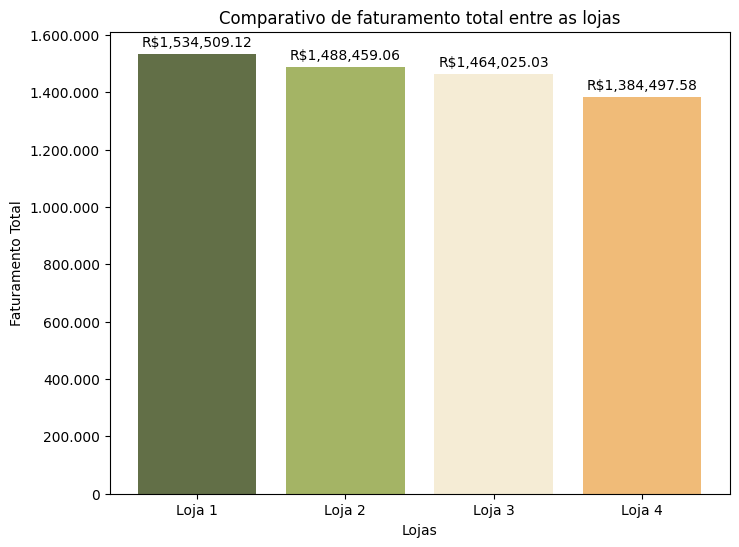

In [125]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LinearLocator

plt.figure(figsize=(8, 6))
plt.bar(lojas, faturamento_lojas, color=["#626F47", "#A4B465", "#F5ECD5", "#F0BB78"])
for i, valor in enumerate(faturamento_lojas):
    plt.text(i, valor + (valor * 0.01), f'R${valor:,.2f}', ha='center', va='bottom')
plt.xticks(lojas)
plt.ylabel("Faturamento Total")
plt.xlabel("Lojas")
plt.title("Comparativo de faturamento total entre as lojas")
formatar_valores_faturamento = FuncFormatter(lambda valor, pos: f'{int(valor):,}'.replace(",", "."))
plt.gca().yaxis.set_major_formatter(formatar_valores_faturamento)

plt.show()

# 2. Vendas por Categoria

In [126]:
categorias_lojas = pd.concat([loja["Categoria do Produto"], loja2["Categoria do Produto"], loja3["Categoria do Produto"], loja4["Categoria do Produto"]])
categorias_existentes = categorias_lojas.unique()

In [127]:
def contar_qntd_vendas_categorias(loja):
    categorias_e_qntd_vendas = {}
    for categoria in categorias_existentes: # laço de repetição para cada categoria que existe
        total_vendas_categoria = loja[loja["Categoria do Produto"] == categoria]["Categoria do Produto"].count() # Separando os itens por categoria e contando
        categorias_e_qntd_vendas[categoria] = int(total_vendas_categoria) # atribuindo valor ao dicionário criado com a categoria e qntd total de vendas da loja
    return categorias_e_qntd_vendas

qntd_vendas_categorias_loja = contar_qntd_vendas_categorias(loja)
qntd_vendas_categorias_loja2 = contar_qntd_vendas_categorias(loja2)
qntd_vendas_categorias_loja3 = contar_qntd_vendas_categorias(loja3)
qntd_vendas_categorias_loja4 = contar_qntd_vendas_categorias(loja4)

In [128]:
valores_loja1 = [qntd_vendas_categorias_loja.get(categoria) for categoria in categorias_existentes]
valores_loja2 = [qntd_vendas_categorias_loja2.get(categoria) for categoria in categorias_existentes]
valores_loja3 = [qntd_vendas_categorias_loja3.get(categoria) for categoria in categorias_existentes]
valores_loja4 = [qntd_vendas_categorias_loja4.get(categoria) for categoria in categorias_existentes]

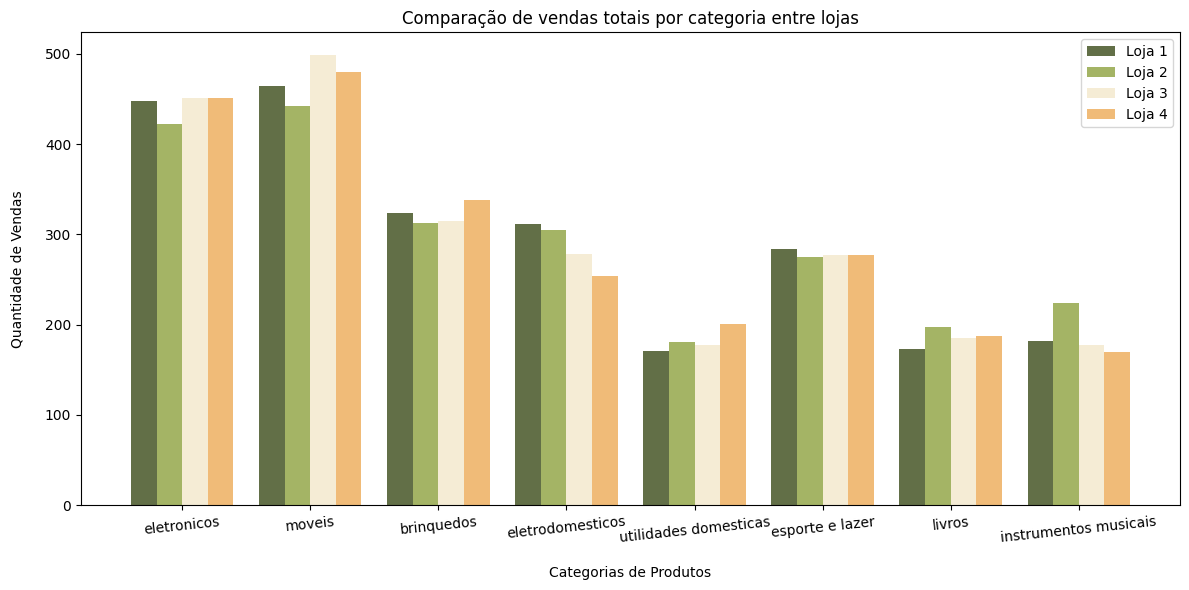


 ELETRONICOS
Loja 1: 448
Loja 2: 422
Loja 3: 451
Loja 4: 451

 MOVEIS
Loja 1: 465
Loja 2: 442
Loja 3: 499
Loja 4: 480

 BRINQUEDOS
Loja 1: 324
Loja 2: 313
Loja 3: 315
Loja 4: 338

 ELETRODOMESTICOS
Loja 1: 312
Loja 2: 305
Loja 3: 278
Loja 4: 254

 UTILIDADES DOMESTICAS
Loja 1: 171
Loja 2: 181
Loja 3: 177
Loja 4: 201

 ESPORTE E LAZER
Loja 1: 284
Loja 2: 275
Loja 3: 277
Loja 4: 277

 LIVROS
Loja 1: 173
Loja 2: 197
Loja 3: 185
Loja 4: 187

 INSTRUMENTOS MUSICAIS
Loja 1: 182
Loja 2: 224
Loja 3: 177
Loja 4: 170


In [129]:
x = np.arange(len(categorias_existentes))
plt.figure(figsize=(12, 6))
plt.bar(x - 1.5*0.2, valores_loja1, width=0.2, label='Loja 1', color='#626F47')
plt.bar(x - 0.5*0.2, valores_loja2, width=0.2, label='Loja 2', color='#A4B465')
plt.bar(x + 0.5*0.2, valores_loja3, width=0.2, label='Loja 3', color='#F5ECD5')
plt.bar(x + 1.5*0.2, valores_loja4, width=0.2, label='Loja 4', color='#F0BB78')
plt.xlabel("Categorias de Produtos", labelpad=15)
plt.ylabel("Quantidade de Vendas", labelpad=15)
plt.title("Comparação de vendas totais por categoria entre lojas")
plt.xticks(x, categorias_existentes, rotation=6)
plt.legend()
plt.tight_layout()
plt.show()

for i, categoria in enumerate(categorias_existentes):
    print(f"\n {categoria.upper()}")
    print(f"Loja 1: {valores_loja1[i]}")
    print(f"Loja 2: {valores_loja2[i]}")
    print(f"Loja 3: {valores_loja3[i]}")
    print(f"Loja 4: {valores_loja4[i]}")

# 3. Média de Avaliação das Lojas


In [130]:
def calcular_media_avaliacao_geral(loja):
    soma_avaliacoes = 0
    qntd_avaliacoes = 0
    for avaliacao in loja["Avaliação da compra"]:
        soma_avaliacoes += avaliacao
        qntd_avaliacoes += 1
    media_avaliacao = soma_avaliacoes / qntd_avaliacoes
    media_avaliacao = round(media_avaliacao, 2)
    return media_avaliacao

In [131]:
avaliacao_loja = calcular_media_avaliacao_geral(loja)
avaliacao_loja2 = calcular_media_avaliacao_geral(loja2)
avaliacao_loja3 = calcular_media_avaliacao_geral(loja3)
avaliacao_loja4 = calcular_media_avaliacao_geral(loja4)


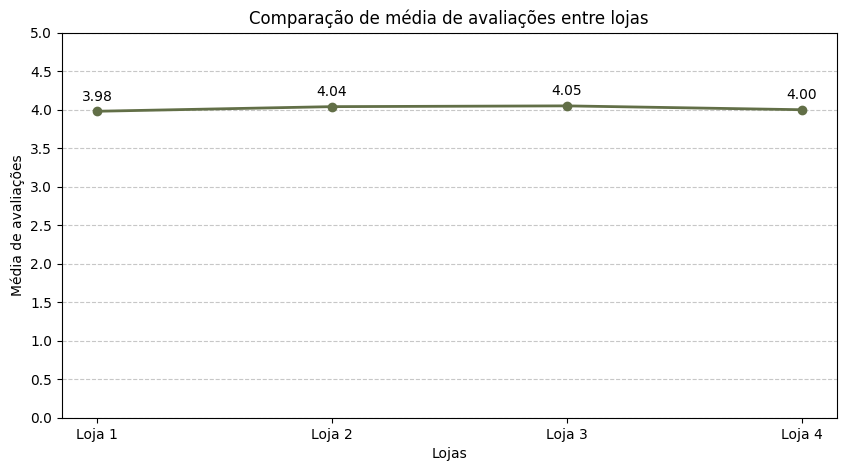

Loja 1 = Média de 3.98
Loja 2 = Média de 4.04
Loja 3 = Média de 4.05
Loja 4 = Média de 4.0


In [132]:
avaliacoes_lojas = [avaliacao_loja, avaliacao_loja2, avaliacao_loja3, avaliacao_loja4]

plt.figure(figsize=(10, 5))

plt.plot(lojas, avaliacoes_lojas, marker='o', linestyle='-', color='#626F47', linewidth=2)

for i, valor in enumerate(avaliacoes_lojas):
    plt.text(i, valor + 0.1, f"{valor:.2f}", ha='center', va='bottom', color='black', fontsize=10)

plt.ylim(0, 5)
plt.yticks(np.arange(0, 5.5, 0.5))

plt.xlabel("Lojas")
plt.ylabel("Média de avaliações")
plt.title("Comparação de média de avaliações entre lojas")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

for i, avaliacao in enumerate(avaliacoes_lojas):
    print(f"Loja {i+1} = Média de {avaliacao}")

# 4. Produtos Mais e Menos Vendidos

In [133]:
def filtrar_produto_mais_e_menos_vendido(loja):
    produto_mais_vendido = loja["Produto"].value_counts().idxmax()
    qntd_produto_mais_vendido = loja['Produto'].value_counts().max()

    produto_menos_vendido = loja["Produto"].value_counts().idxmin()
    qntd_produto_menos_vendido = loja['Produto'].value_counts().min()
    return (produto_mais_vendido, qntd_produto_mais_vendido, produto_menos_vendido, qntd_produto_menos_vendido)


produto_mais_vendido_loja, qntd_produto_mais_vendido, produto_menos_vendido_loja, qntd_produto_menos_vendido = filtrar_produto_mais_e_menos_vendido(loja)
produto_mais_vendido_loja2, qntd_produto_mais_vendido2, produto_menos_vendido_loja2, qntd_produto_menos_vendido2 = filtrar_produto_mais_e_menos_vendido(loja2)
produto_mais_vendido_loja3, qntd_produto_mais_vendido3, produto_menos_vendido_loja3, qntd_produto_menos_vendido3 = filtrar_produto_mais_e_menos_vendido(loja3)
produto_mais_vendido_loja4, qntd_produto_mais_vendido4, produto_menos_vendido_loja4, qntd_produto_menos_vendido4 = filtrar_produto_mais_e_menos_vendido(loja4)


produtos_mais_vendidos = [produto_mais_vendido_loja, produto_mais_vendido_loja2, produto_mais_vendido_loja3, produto_mais_vendido_loja4]
qtds_mais_vendidos = [qntd_produto_mais_vendido, qntd_produto_mais_vendido2, qntd_produto_mais_vendido3, qntd_produto_mais_vendido4]
produtos_menos_vendidos = [produto_menos_vendido_loja, produto_menos_vendido_loja2, produto_menos_vendido_loja3, produto_menos_vendido_loja4]
qtds_menos_vendidos = [qntd_produto_menos_vendido, qntd_produto_menos_vendido2, qntd_produto_menos_vendido3, qntd_produto_menos_vendido4]


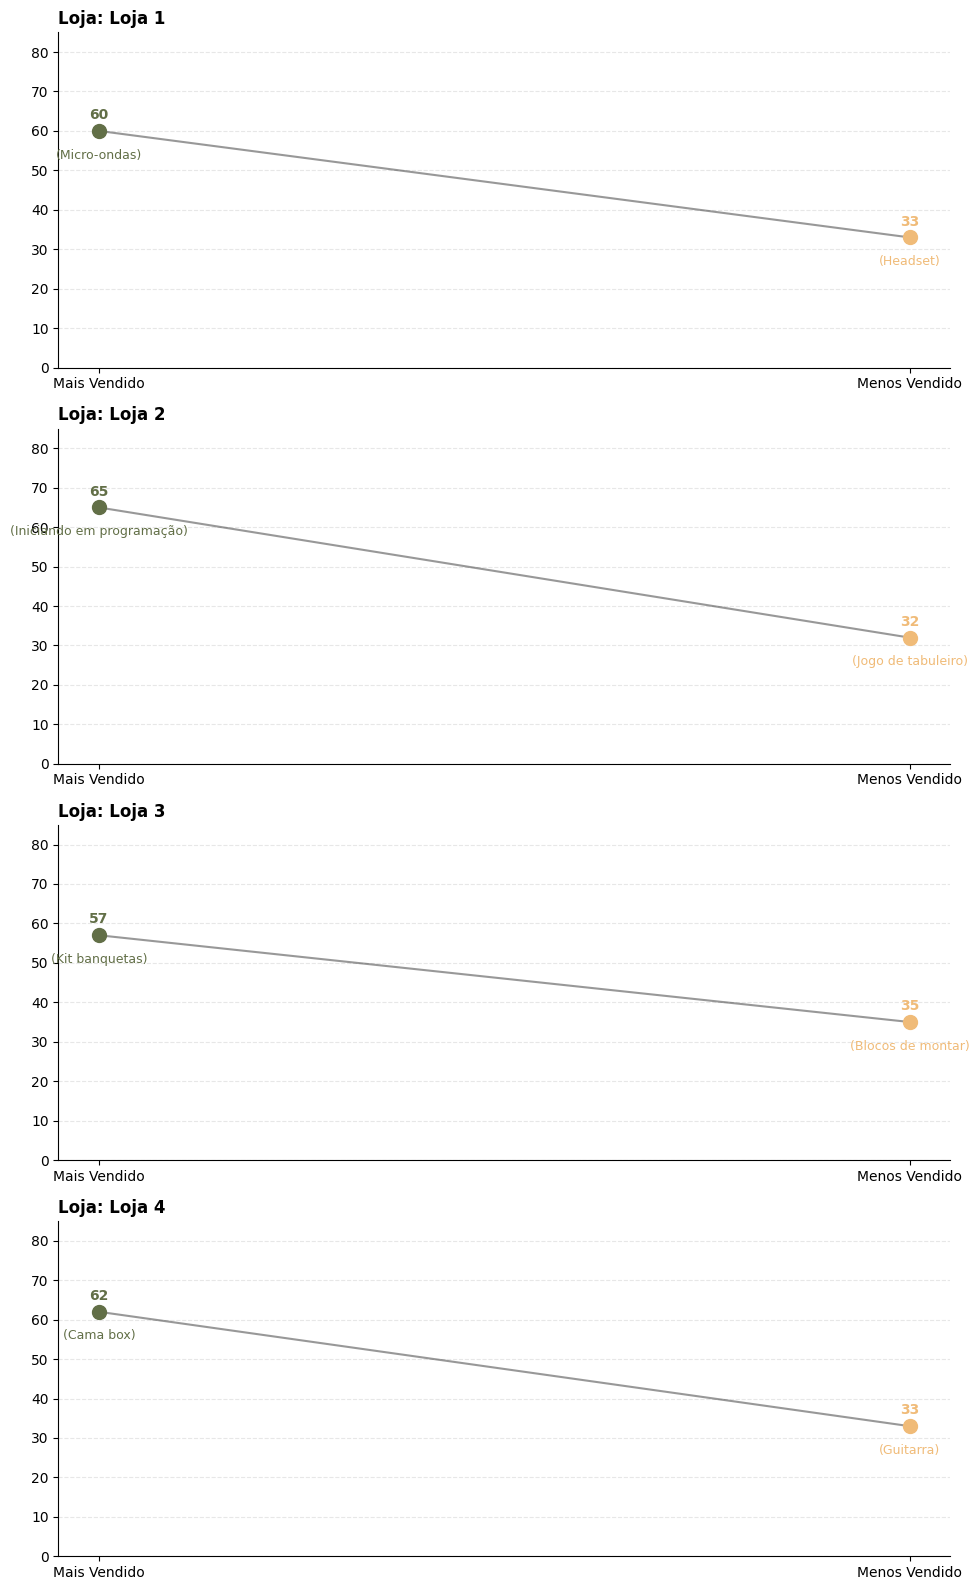

 Loja 1
Produto mais vendido: Micro-ondas - 60.
Produto menos vendido: Headset - 33.

 Loja 2
Produto mais vendido: Iniciando em programação - 65.
Produto menos vendido: Jogo de tabuleiro - 32.

 Loja 3
Produto mais vendido: Kit banquetas - 57.
Produto menos vendido: Blocos de montar - 35.

 Loja 4
Produto mais vendido: Cama box - 62.
Produto menos vendido: Guitarra - 33.



In [134]:
fig, axs = plt.subplots(len(lojas), 1, figsize=(10, 4 * len(lojas)), sharey=True)

if len(lojas) == 1:
    axs = [axs]

for i, loja in enumerate(lojas):
    ax = axs[i]

    categorias = ['Mais Vendido', 'Menos Vendido']
    valores = [qtds_mais_vendidos[i], qtds_menos_vendidos[i]]
    nomes_produtos = [produtos_mais_vendidos[i], produtos_menos_vendidos[i]]
    cores = ['#626F47', '#F0BB78']

    ax.plot(categorias, valores, marker='o', linestyle='-', color='#333333', alpha=0.5)

    for j in range(len(categorias)):
        ax.scatter(categorias[j], valores[j], color=cores[j], s=100, zorder=5)

        ax.text(categorias[j], valores[j] + 3, f"{valores[j]}",
                ha='center', fontweight='bold', color=cores[j])

        ax.text(categorias[j], valores[j] - 7, f"({nomes_produtos[j]})",
                ha='center', fontsize=9, color=cores[j])


    ax.set_title(f"Loja: {loja}", loc='left', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 85)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

for i in range (0,4):
    print(f" Loja {i+1}")
    print(f"Produto mais vendido: {produtos_mais_vendidos[i]} - {qtds_mais_vendidos[i]}.")
    print(f"Produto menos vendido: {produtos_menos_vendidos[i]} - {qtds_menos_vendidos[i]}.\n")

# 5. Frete Médio por Loja

In [135]:
loja = {"Nome": "Loja 1", "Frete": [10.50, 20.90, 15.00]}
loja2 = {"Nome": "Loja 2", "Frete": [8.00, 12.50, 11.00]}
loja3 = {"Nome": "Loja 3", "Frete": [25.00, 30.00, 22.00]}
loja4 = {"Nome": "Loja 4", "Frete": [10.00, 5.00, 12.00]}

def calcular_frete_medio(loja_dict):
    total = sum(loja_dict["Frete"])
    quantidade = len(loja_dict["Frete"])
    return round(total / quantidade, 2)

frete_loja = calcular_frete_medio(loja)

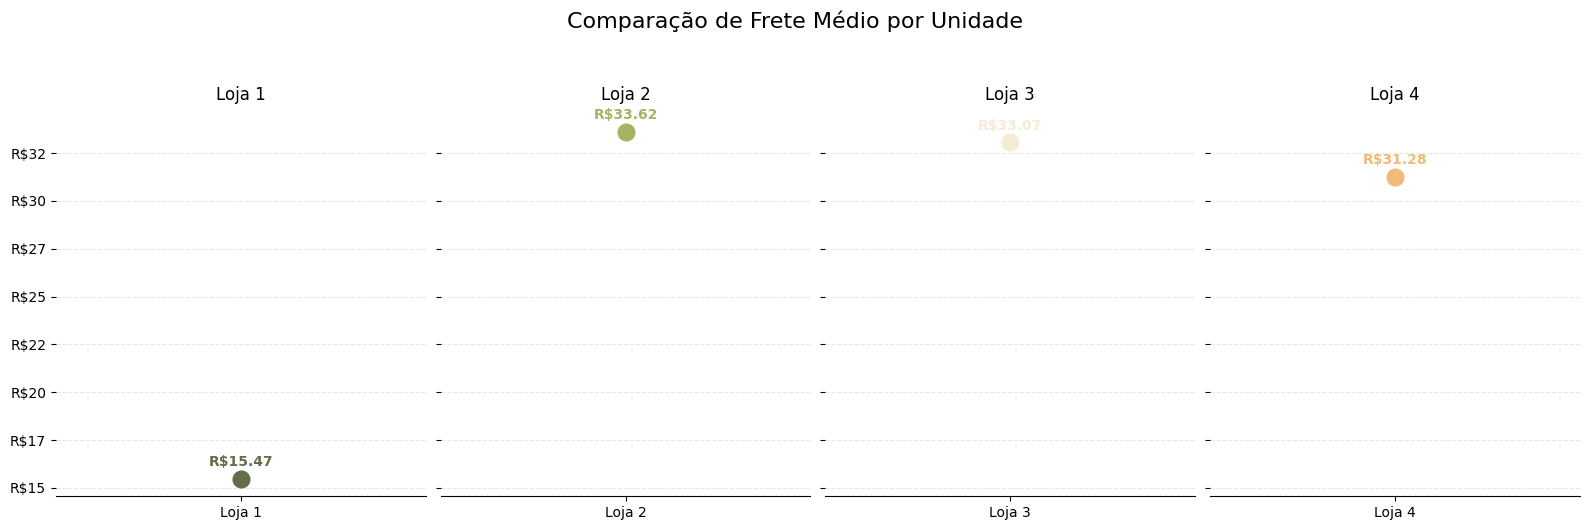

------------------------------
 Loja 1 = Frete Médio de R$15.47
 Loja 2 = Frete Médio de R$33.62
 Loja 3 = Frete Médio de R$33.07
 Loja 4 = Frete Médio de R$31.28


In [136]:
frete_lojas = [frete_loja, frete_loja2, frete_loja3, frete_loja4]
nomes_lojas = ["Loja 1", "Loja 2", "Loja 3", "Loja 4"]
cores = ["#626F47", "#A4B465", "#F5ECD5", "#F0BB78"]

fig, axs = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
plt.subplots_adjust(wspace=0.4)

formatter = FuncFormatter(lambda valor, pos: f'R${int(valor):,}' .replace(",", "."))

for i, ax in enumerate(axs):

    ax.plot([nomes_lojas[i]], [frete_lojas[i]], marker='o', markersize=12, color=cores[i])

    ax.text(0, frete_lojas[i] + 0.5, f'R${frete_lojas[i]:.2f}',
            ha='center', va='bottom', fontweight='bold', color=cores[i])

    ax.set_title(nomes_lojas[i], fontsize=12, pad=10)
    ax.yaxis.set_major_formatter(formatter)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

fig.suptitle("Comparação de Frete Médio por Unidade", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

print("-" * 30)
for i, valor in enumerate(frete_lojas):
    print(f" {nomes_lojas[i]} = Frete Médio de R${valor:.2f}")

# Relatório Final


Após todas as análises, a loja que deve ser vendida é a loja 4, devido ao seu baixo desempenho em comparação às outras lojas: ela possui o menor faturamento, é a segunda pior nas avaliações de clientes e não possui nenhuma categoria de venda sobressalente.